In [18]:
import torch 
import trimesh 
import os 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sea

plt.style.use('ggplot')
colormap1 = plt.get_cmap('Reds')
colormap2 = plt.get_cmap('Blues')

gripper = trimesh.load('../gripper.obj')

### Load all the output files

In [19]:
TEMP_DIR = '../temp/'

output = trimesh.load(f'{TEMP_DIR}/only_output_mesh.obj') # the object mesh used during inference
pred_grasps = torch.load(f'{TEMP_DIR}/ouput_dual_grasps.pt').detach().cpu().numpy() # predicted grasps
energy = torch.load(f'{TEMP_DIR}/output_energy.pt').detach().cpu().numpy() # predicted grasp energies
traj = torch.load(f'{TEMP_DIR}/grasps_traj.pt') # the denoising trajectory
fc_scores = torch.load(f'{TEMP_DIR}/grasp_scores.pt').reshape(-1) # predicted force-closure scores
collision_scores = torch.load(f'{TEMP_DIR}/collision_scores.pt').reshape(-1, 2) # predicted collision scores
P = torch.load(f'{TEMP_DIR}/point_cloud.pt').reshape(-1, 3)
rot = torch.load(f'{TEMP_DIR}/rotation.pt') # random rotation applied during inference
reach_scores = torch.load(f'{TEMP_DIR}/reach_label_scores.pt').reshape(-1)
pcd = trimesh.PointCloud(P @ rot)
pcd.colors = [255, 0, 0]

print(reach_scores.shape, fc_scores.shape)
T = np.eye(4)
T[:3, :3] = rot.T

pred_grasps = T[None, None, ...] @ pred_grasps
traj = T[None, None, ...] @ traj
output.apply_transform(T)

reach_cmap = plt.get_cmap('viridis')
reach_norm = mpl.colors.Normalize(vmin=float(np.min(reach_scores)), vmax=float(np.max(reach_scores)))

def reach_color(score):
    rgba = reach_cmap(reach_norm(float(score)))
    return [int(255 * rgba[0]), int(255 * rgba[1]), int(255 * rgba[2]), 255]


(300,) (300,)


### Preprocess the files

- Here, we sort all the generated grasp pairs by the energy value.

- Lower energy corresponds to grasps physically grounded on the object surface while higher energy means the grasp pairs are still floating in the free space.

- Some grasps will have lower `Force-Closure Score`, which can be removed by thresholding


<Axes: title={'center': 'Reach Score'}, ylabel='Count'>

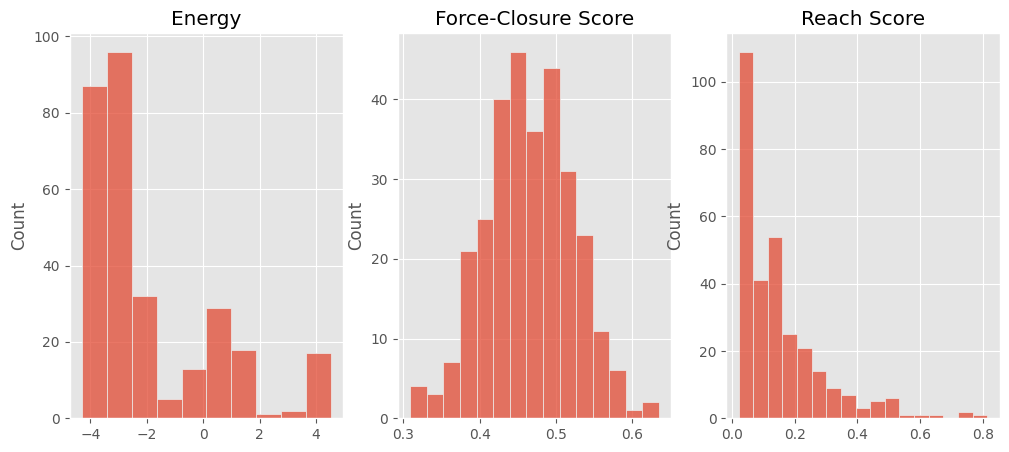

In [20]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title('Energy')
sea.histplot(energy)

plt.subplot(1, 3, 2)
plt.title('Force-Closure Score')
sea.histplot(fc_scores)

plt.subplot(1,3,3)
plt.title('Reach Score')
sea.histplot(reach_scores)

In [30]:
# idx = np.argsort(energy)[200]
idx = 6

gripper_left = gripper.copy()
gripper_right = gripper.copy()

gripper_left.apply_transform(pred_grasps[idx, 0])
gripper_left.visual.face_colors = reach_color(reach_scores[idx])
gripper_right.apply_transform(pred_grasps[idx, 1])


print(f"Energy: {energy[idx].item()}")
print(f'Force-Closure Score: {fc_scores[idx].item()}')
print(f'Collision Score: {collision_scores[idx]}')
print(f'Reach Score: {reach_scores[idx]}')


Energy: 0.07701106369495392
Force-Closure Score: 0.4954381287097931
Collision Score: [0.44603148 0.47951376]
Reach Score: 0.12370984256267548


### Visualize the predicted dual-arm grasps

- Change the above `idx` to view different grasps

In [37]:
grippers_left, grippers_right = [], []
spheres_left, spheres_right = [], []
lines = []

traj_now = []

# Final pose for each grasp is stored at the last trajectory step.
final_step = len(traj) - 1

for g in range(len(reach_scores)):
    grasp_color = reach_color(reach_scores[g])

    gripper_left_temp = gripper.copy()
    gripper_left_temp.visual.face_colors = grasp_color
    gripper_left_temp.apply_transform(traj[final_step, 2*g, ...])
    sphere = trimesh.creation.icosphere(radius=0.005)
    sphere.apply_translation(traj[final_step, 2*g, :3, 3])
    sphere.visual.face_colors = grasp_color
    spheres_left.append(sphere)
    grippers_left.append(gripper_left_temp)

    gripper_right_temp = gripper.copy()
    gripper_right_temp.visual.face_colors = grasp_color
    gripper_right_temp.apply_transform(traj[final_step, 2*g + 1, ...])
    grippers_right.append(gripper_right_temp)
    sphere = trimesh.creation.icosphere(radius=0.005)
    sphere.apply_translation(traj[final_step, 2*g + 1, :3, 3])
    sphere.visual.face_colors = grasp_color
    spheres_right.append(sphere)

    traj_now.append(np.asarray([traj[final_step, 2*g, ...], traj[final_step, 2*g + 1, ...]]))

traj_now = np.asarray(traj_now)

coordinate_frame = trimesh.creation.axis(origin_size=1e-2)

scene = trimesh.Scene([output, pcd, coordinate_frame, *grippers_left, *grippers_right])

sm = plt.cm.ScalarMappable(cmap=reach_cmap, norm=reach_norm)
sm.set_array([])
plt.figure(figsize=(7, 1))
plt.show()

scene.show()


<Figure size 700x100 with 0 Axes>

### Visualize the denoising trajectory

In [32]:
skip_steps = 10
lines = []
show_lines = False

if show_lines:
    for i in range(0, len(spheres_left)-skip_steps, skip_steps):
        line = trimesh.creation.cylinder(radius=0.00025, 
                                        segment=[spheres_left[i].centroid, spheres_left[i+skip_steps].centroid])
        lines.append(line)
        
        line = trimesh.creation.cylinder(radius=0.00025,
                                        segment=[spheres_right[i].centroid, spheres_right[i+skip_steps].centroid])
        lines.append(line)

scene = trimesh.Scene([output, pcd, grippers_left[::skip_steps], grippers_right[::skip_steps], 
                       coordinate_frame, spheres_left[::skip_steps], spheres_right[::skip_steps],    
                       lines if show_lines else None])
scene.show()